## Lecture Section

NOTE: THIS IS A FREE LECTURE
I trust that you will read through the assignment and submit it on Gradescope. As long as you submit it, I will give you the 10 points!
Good luck on your finals, and don't forget to finish up the final project and your discussions!

In this lecture, we will introduce some aspects of nonparametric methods. We will cover:

* What are nonparametric methods?
* KDE
* KNN (Classification - not Clustering)
* Nonparametric Hypothesis Tests
    * Mann-Whitney U
    * Kruskal-Wallis Test

### Nonparametric Methods

All of the things we learned throughout the semester assumed normality or some other type of underlying distribution. These distributions can be defined by some set of parameters. For example, a normal distribution can be defined by the parameters mu and var: mean and standard deviation/variance.

Sometimes, we cannot assume the underlying distribution of our data. In that case, nonparametric methods are needed for us to solve problems and analyze datasets.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    root_mean_squared_error, r2_score
)


### Kernel Density Estimation (KDE)

Before modeling, we often want to understand the *shape* of our data without assuming a specific distribution. **KDE** is a nonparametric way to estimate the probability density function of a variable.

A histogram bins data into fixed intervals — the shape depends heavily on where you place the bin boundaries. KDE instead places a smooth **kernel** (a small bump function) on top of each data point, then sums them all up. The result is a smooth density curve:

$$\hat{f}(x) = \frac{1}{nh} \sum_{i=1}^{n} K\!\left(\frac{x - x_i}{h}\right)$$

Where:
- $n$ = number of observations
- $h$ = **bandwidth** — the key tuning parameter, controls smoothness
- $K$ = the kernel function (commonly Gaussian: $K(u) = \frac{1}{\sqrt{2\pi}}e^{-u^2/2}$)

**Small bandwidth** → wiggly, high-variance estimate that overfits to the sample
**Large bandwidth** → over-smoothed, high-bias estimate that obscures real structure

Seaborn uses `scipy.stats.gaussian_kde` under the hood when you call `kdeplot()`.

Below is the Old Faithful geyser dataset
* eruptions: duration of each eruption in minutes
* waiting: waiting time until next eruption


In [7]:
geyser = sns.load_dataset('geyser')
print(geyser.head())
print(f'\nShape: {geyser.shape}')

   duration  waiting   kind
0     3.600       79   long
1     1.800       54  short
2     3.333       74   long
3     2.283       62  short
4     4.533       85   long

Shape: (272, 3)


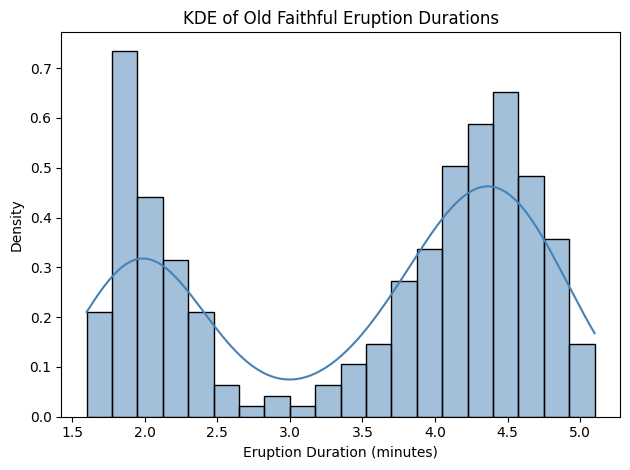

In [8]:
fig, ax = plt.subplots()
sns.histplot(geyser['duration'], kde=True, stat='density',
             bins=20, color='steelblue', ax=ax)
ax.set_xlabel('Eruption Duration (minutes)')
ax.set_ylabel('Density')
ax.set_title('KDE of Old Faithful Eruption Durations')
plt.tight_layout()
plt.show()

The bimodal shape reveals TWO eruption regimes.
* short eruptions (2 min) and long eruptions (4.5 min)
* a normality assumption would completely miss this structure.

#### Bandwidth Matters

In seaborn's `kdeplot`, the `bw_adjust` parameter *multiplies* the default bandwidth (Scott's rule). So `bw_adjust=0.25` means one-quarter of the default — very tight — and `bw_adjust=3` means three times the default — very smooth.

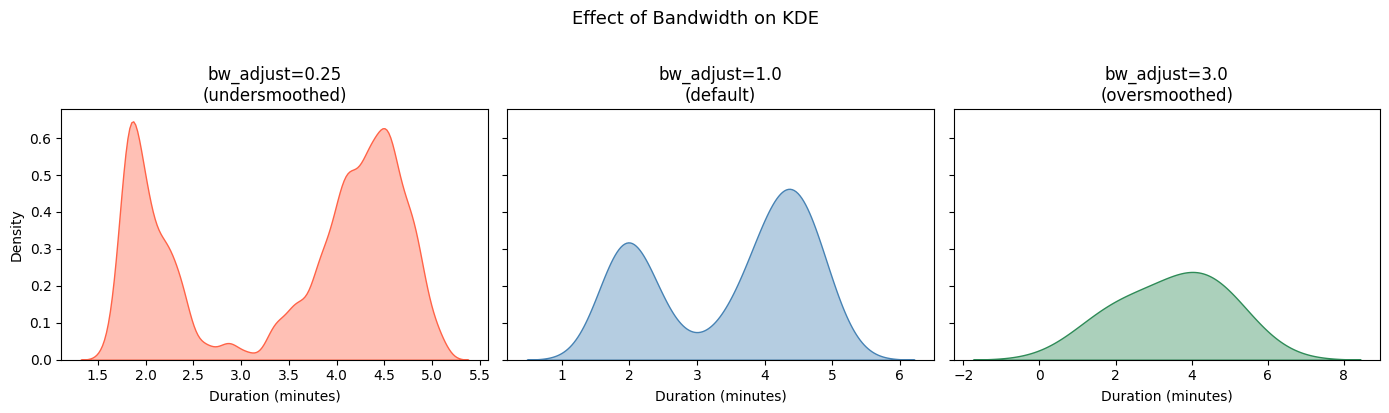

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
bw_settings = [0.25, 1.0, 3.0]
labels = ['bw_adjust=0.25\n(undersmoothed)', 'bw_adjust=1.0\n(default)', 'bw_adjust=3.0\n(oversmoothed)']
colors = ['tomato', 'steelblue', 'seagreen']

for ax, bw, label, color in zip(axes, bw_settings, labels, colors):
    sns.kdeplot(geyser['duration'], bw_adjust=bw, color=color, fill=True,
                alpha=0.4, ax=ax)
    ax.set_title(label)
    ax.set_xlabel('Duration (minutes)')

axes[0].set_ylabel('Density')
plt.suptitle('Effect of Bandwidth on KDE', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()



### K-Nearest Neighbors — Classification

KNN is one of the simplest supervised learning algorithms. To classify a new point, it finds the $K$ training observations **closest** to it in feature space and takes a **majority vote** among their labels.

1. Choose a value of $K$
2. For a new point $x^*$, compute the distance to every training point (typically Euclidean: $d(x, x') = \sqrt{\sum_{j=1}^{p}(x_j - x'_j)^2}$)
3. Find the $K$ closest training points — the **neighborhood**
4. Assign $x^*$ the most common class among those $K$ neighbors


Because KNN relies on distance, a feature measured in thousands (e.g., income) will dominate one measured in single digits (e.g., age). **Always standardize features before running KNN.**

**IMPORTANT** Fit the scaler on the *training set only*, then apply those same parameters to the test set. Fitting on the test set would be data leakage — in deployment you won't have test set statistics available.

In [10]:
# Load the Iris dataset: predict Species from petal/sepal measurements
iris = load_iris(as_frame=True)
X = iris.data
y = iris.target

# 70/30 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale: fit on training set ONLY, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Test Accuracy (K=5): 0.9111


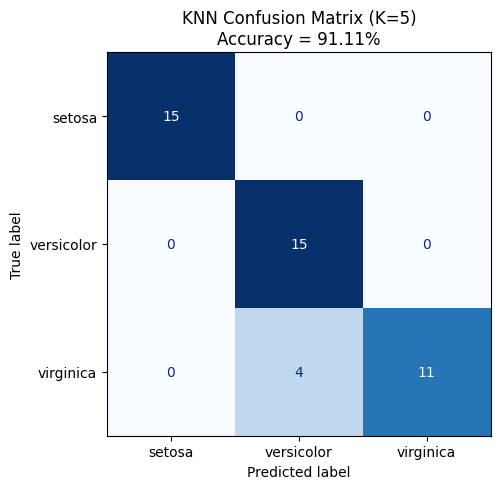

In [11]:
# Fit KNN with K=5
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scaled, y_train)
y_pred = knn_clf.predict(X_test_scaled)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy (K=5): {acc:.4f}')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=iris.target_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'KNN Confusion Matrix (K=5)\nAccuracy = {acc:.2%}')
plt.tight_layout()
plt.show()

# Diagonal = correct predictions
# Off-diagonal = misclassifications (which classes get confused with which)

###  Nonparametric Hypothesis Tests

When data are clearly non-normal, ordinal, or small-sample, nonparametric tests offer robust alternatives to $t$-tests and ANOVA. They work with **ranks** rather than raw values, making them resistant to outliers and distributional assumptions.

We'll use the `lung` (`cancer`) dataset (advanced lung cancer patients), loaded directly from R's `survival` package via `statsmodels`

Censored means the person being recorded stopped responding to the study but they had not yet died - everyone is either dead or censored

In [15]:
# Load lung data from R's survival package via statsmodels
lung = sm.datasets.get_rdataset('cancer', 'survival').data

# Recode status: 1=censored -> 0, 2=dead -> 1
lung['status'] = lung['status'].map({1: 0, 2: 1})
lung['sex'] = lung['sex'].map({1: 'Male', 2: 'Female'})

print(lung[['time', 'status', 'sex', 'ph.ecog', 'meal.cal']].head(10))
print(f'\nStatus counts:\n{lung["status"].value_counts()}')

   time  status     sex  ph.ecog  meal.cal
0   306       1    Male      1.0    1175.0
1   455       1    Male      0.0    1225.0
2  1010       0    Male      0.0       NaN
3   210       1    Male      1.0    1150.0
4   883       1    Male      0.0       NaN
5  1022       0    Male      1.0     513.0
6   310       1  Female      2.0     384.0
7   361       1  Female      2.0     538.0
8   218       1    Male      1.0     825.0
9   166       1    Male      2.0     271.0

Status counts:
status
1    165
0     63
Name: count, dtype: int64


### Wilcoxon Rank-Sum Test (Mann-Whitney U)

Tests whether two groups come from the same distribution — roughly, whether one group tends to have larger values than the other. The variable you are measuring needs to be ordinal in some way.

**Hypotheses:**
- $H_0$: The two populations have the same distribution
- $H_a$: One population tends to produce larger values (or: the distributions differ)

The test works by ranking all observations across both groups combined, then checking whether one group's ranks are systematically higher.

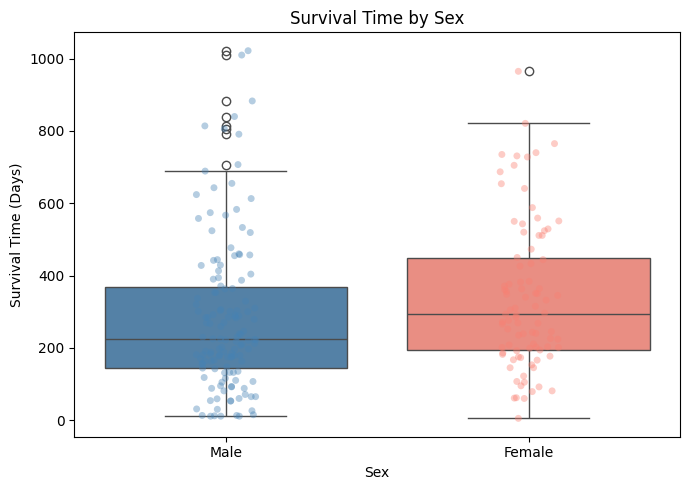

Wilcoxon Rank-Sum Test (Mann-Whitney U)
  H0: Survival times have the same distribution for males and females
  Ha: Distributions differ
  Statistic: 5006.00
  p-value:   0.0134

  At alpha=0.05, we REJECT H0.
  There is significant evidence that survival time differs by sex.


In [13]:
# Do male and female lung cancer patients have different survival times?
male_times   = lung.loc[lung['sex'] == 'Male',   'time'].dropna()
female_times = lung.loc[lung['sex'] == 'Female', 'time'].dropna()

# Visualize first — always look before you test
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=lung.dropna(subset=['time']),
            x='sex', y='time', hue='sex',
            palette={'Male': 'steelblue', 'Female': 'salmon'},
            ax=ax, legend=False)
sns.stripplot(data=lung.dropna(subset=['time']),
              x='sex', y='time', hue='sex',
              palette={'Male': 'steelblue', 'Female': 'salmon'},
              alpha=0.4, jitter=True, ax=ax, legend=False)
ax.set_xlabel('Sex')
ax.set_ylabel('Survival Time (Days)')
ax.set_title('Survival Time by Sex')
plt.tight_layout()
plt.show()

# Wilcoxon rank-sum test
# alternative='two-sided': test whether either group tends to be larger
stat, p_value = stats.mannwhitneyu(male_times, female_times, alternative='two-sided')
print(f'Wilcoxon Rank-Sum Test (Mann-Whitney U)')
print(f'  H0: Survival times have the same distribution for males and females')
print(f'  Ha: Distributions differ')
print(f'  Statistic: {stat:.2f}')
print(f'  p-value:   {p_value:.4f}')
print()
alpha = 0.05
if p_value < alpha:
    print(f'  At alpha={alpha}, we REJECT H0.')
    print('  There is significant evidence that survival time differs by sex.')
else:
    print(f'  At alpha={alpha}, we FAIL TO REJECT H0.')
    print('  Insufficient evidence of a difference.')

### Kruskal-Wallis Test

Extends the Wilcoxon rank-sum to three or more groups. Popular as a replacement for `ANOVA`

**Hypotheses:**
- $H_0$: All groups come from the same distribution
- $H_a$: At least one group's distribution differs

We'll test whether survival time differs across ECOG performance score groups (`ph.ecog`):
0 = asymptomatic, 1 = symptomatic but ambulatory, 2 = in bed <50% of day, 3 = in bed >50% of day

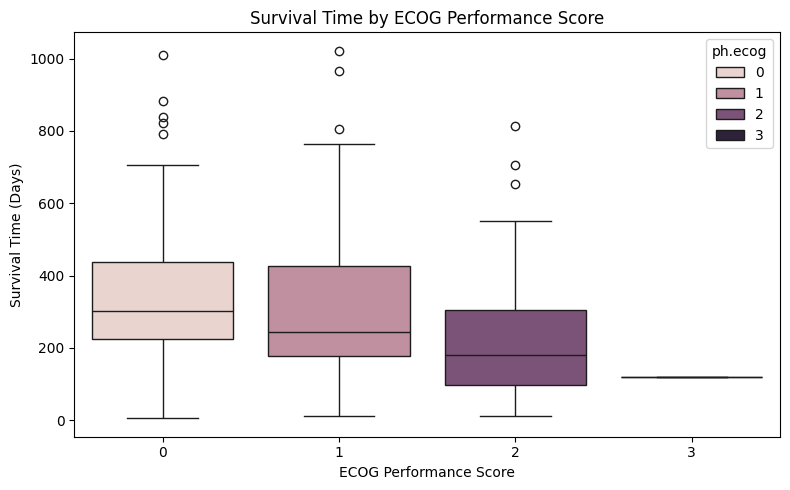

Group sizes: {np.int64(0): 63, np.int64(1): 113, np.int64(2): 50, np.int64(3): 1}

Kruskal-Wallis Test
  H0: Survival time has the same distribution across all ECOG groups
  Ha: At least one group's distribution differs
  H-statistic: 14.1582
  p-value:     0.0027
  REJECT H0 — at least one group differs significantly.
  --> Run pairwise tests to identify which pairs differ.


In [16]:
# Drop rows with missing ecog or time
lung_clean = lung.dropna(subset=['ph.ecog', 'time']).copy()
lung_clean['ph.ecog'] = lung_clean['ph.ecog'].astype(int)

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=lung_clean, x='ph.ecog', y='time',
            hue='ph.ecog', ax=ax)
ax.set_xlabel('ECOG Performance Score')
ax.set_ylabel('Survival Time (Days)')
ax.set_title('Survival Time by ECOG Performance Score')
plt.tight_layout()
plt.show()

# Extract groups as separate arrays for scipy
groups = [grp['time'].values for _, grp in lung_clean.groupby('ph.ecog')]
print('Group sizes:', {k: len(v) for k, v in zip(sorted(lung_clean['ph.ecog'].unique()), groups)})

# Kruskal-Wallis test
stat_kw, p_kw = stats.kruskal(*groups)
print(f'\nKruskal-Wallis Test')
print(f'  H0: Survival time has the same distribution across all ECOG groups')
print(f'  Ha: At least one group\'s distribution differs')
print(f'  H-statistic: {stat_kw:.4f}')
print(f'  p-value:     {p_kw:.4f}')
if p_kw < 0.05:
    print('  REJECT H0 — at least one group differs significantly.')
    print('  --> Run pairwise tests to identify which pairs differ.')
else:
    print('  FAIL TO REJECT H0.')

Great Lecture, Thank you!